In [6]:
# Step 0: Install xgboost
!pip install xgboost

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Import XGBoost classifier
from xgboost import XGBClassifier

# Import train/test split
from sklearn.model_selection import train_test_split

# Import evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



Original Dataset:
    Age  Income  Purchased
0    22   20000          0
1    25   25000          0
2    30   30000          0
3    45   80000          1
4    50   90000          1
5    35   50000          1
6    28   35000          0
7    40   70000          1
8    23   22000          0
9    48   85000          1
10   33   45000          1
11   52   95000          1

X_train:
    Age  Income
8    23   22000
5    35   50000
2    30   30000
1    25   25000
11   52   95000
4    50   90000
7    40   70000
3    45   80000
6    28   35000

X_test:
    Age  Income
10   33   45000
9    48   85000
0    22   20000

Predictions on Test Data:
[1 1 1]

Model Accuracy: 0.6666666666666666

Confusion Matrix:
[[0 1]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.

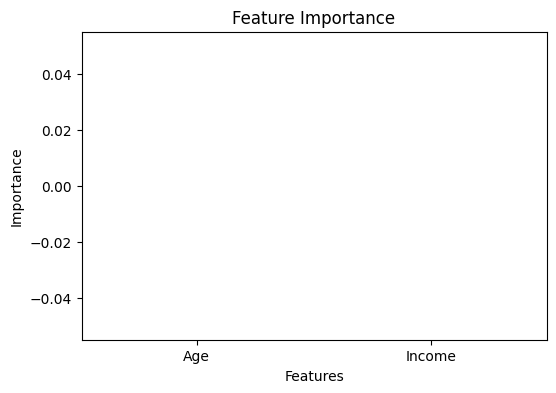

In [7]:
# Step 2: Create sample dataset
# Age and Income are input features
# Purchased is the output/label
data = {
    "Age": [22, 25, 30, 45, 50, 35, 28, 40, 23, 48, 33, 52],
    "Income": [20000, 25000, 30000, 80000, 90000, 50000, 35000, 70000, 22000, 85000, 45000, 95000],
    "Purchased": [0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1]   # 0 = Not Purchased, 1 = Purchased
}

# Convert dictionary into DataFrame
df = pd.DataFrame(data)

print("Original Dataset:")
print(df)


# Step 3: Split dataset into features (X) and label (y)
X = df[["Age", "Income"]]   # Input features
y = df["Purchased"]         # Output label


# Step 4: Split data into training and testing sets
# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nX_train:")
print(X_train)

print("\nX_test:")
print(X_test)


# Step 5: Create XGBoost model
# n_estimators = number of trees
# max_depth = maximum depth of each tree
# learning_rate = how fast the model learns
model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)


# Step 6: Train the model
model.fit(X_train, y_train)


# Step 7: Make predictions on test data
predictions = model.predict(X_test)

print("\nPredictions on Test Data:")
print(predictions)


# Step 8: Calculate model accuracy
accuracy = accuracy_score(y_test, predictions)
print("\nModel Accuracy:", accuracy)


# Step 9: Show confusion matrix
cm = confusion_matrix(y_test, predictions)
print("\nConfusion Matrix:")
print(cm)


# Step 10: Show classification report
# zero_division=0 avoids warning when a class is not predicted
print("\nClassification Report:")
print(classification_report(y_test, predictions, zero_division=0))


# Step 11: Predict for a new customer
# Example customer:
# Age = 32
# Income = 60000
new_customer = pd.DataFrame({
    "Age": [32],
    "Income": [60000]
})

new_prediction = model.predict(new_customer)
print("\nPrediction for new customer (1 = Buy, 0 = Not Buy):", new_prediction)


# Step 12: Predict probabilities for the new customer
# First value = probability of class 0
# Second value = probability of class 1
new_probability = model.predict_proba(new_customer)
print("\nPrediction Probabilities for new customer:")
print(new_probability)


# Step 13: Show feature importance safely
# This avoids the plot_importance() error you got
importance_values = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_values
})

print("\nFeature Importance:")
print(importance_df)


# Step 14: Plot feature importance manually
plt.figure(figsize=(6, 4))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()